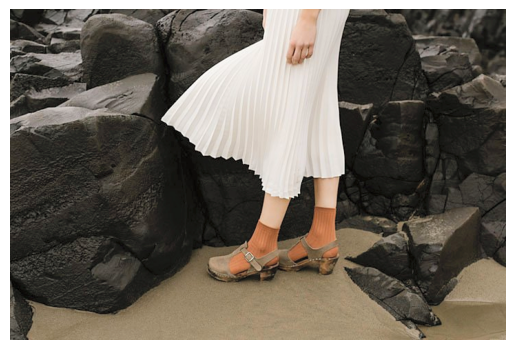

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

img  = cv2.imread('a1images/highlights_and_shadows.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)

l_channel, a_channel, b_channel = cv2.split(img_lab) # Split channels (L is Luminance, a and b are color components)

# Normalize L channel to [0, 1] for Gamma Correction --- L ranges from 0 to 100 in LAB space
l_norm = l_channel.astype(np.float32) / 255.0

# (a) Apply Gamma Correction -- gamma < 1 brightens shadows, gamma > 1 darkens highlights
gamma = 0.7
l_gamma = np.power(l_norm, gamma)

l_corrected = (l_gamma * 255).astype(np.uint8) # # Convert back to uint8 [0,255]

img_lab_corrected = cv2.merge([l_corrected, a_channel, b_channel]) # Merge channels
img_corrected_rgb = cv2.cvtColor(img_lab_corrected, cv2.COLOR_Lab2RGB) # Convert back to RGB for display

# Save result
cv2.imwrite('results/ques2/gamma_corrected.png', cv2.cvtColor(img_corrected_rgb, cv2.COLOR_RGB2BGR))
plt.imshow(img_corrected_rgb)
plt.axis('off')
plt.show()



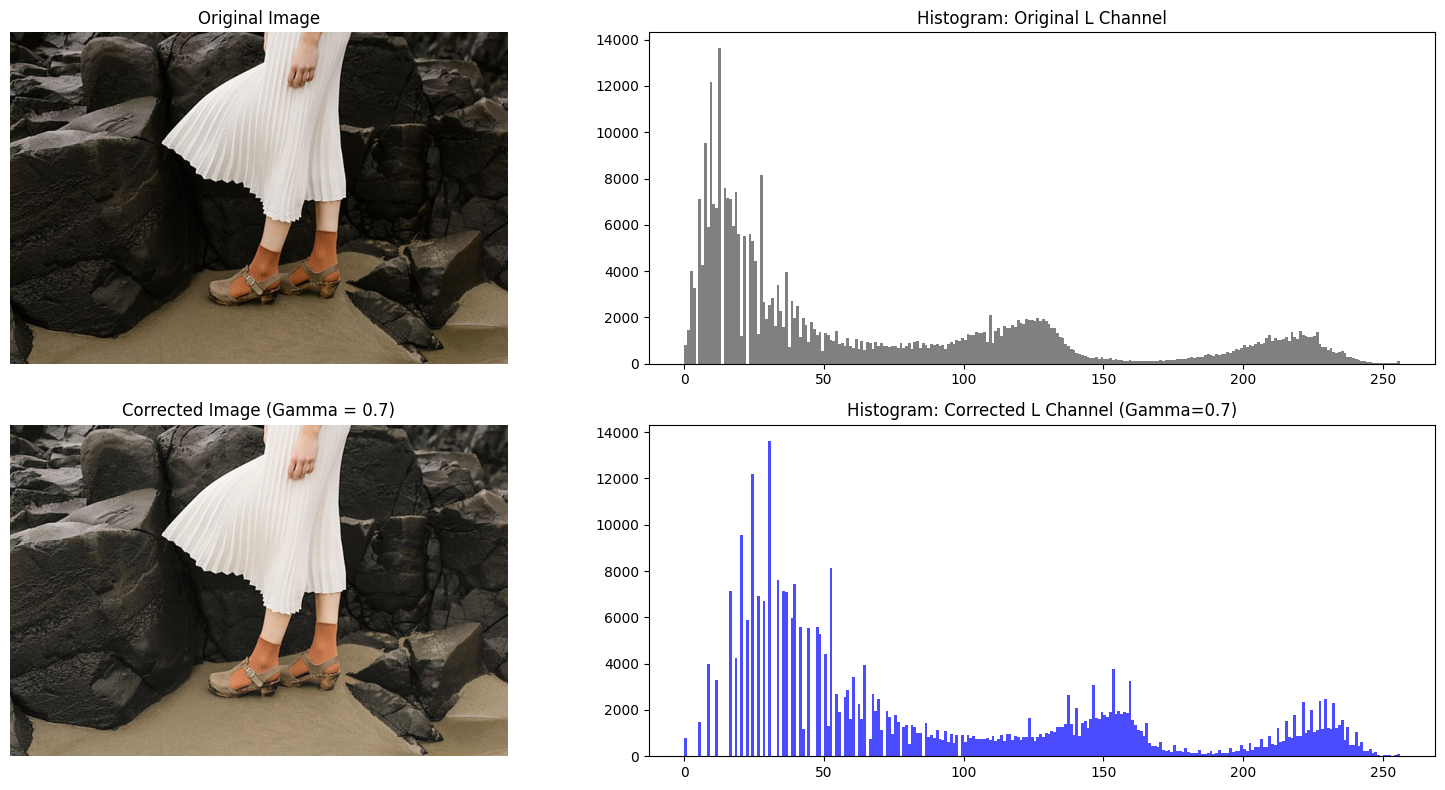

In [24]:
# --- (b) Visualization and Histograms ---
plt.figure(figsize=(16, 8))

# Original Image & Histogram
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.hist(l_channel.ravel(), bins=256, color='gray', range=[0, 256])
plt.title("Histogram: Original L Channel")

# Corrected Image & Histogram
plt.subplot(2, 2, 3)
plt.imshow(img_corrected_rgb)
plt.title(f"Corrected Image (Gamma = {gamma})")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.hist(l_corrected.ravel(), bins=256, color='blue', alpha=0.7, range=[0, 256])
plt.title(f"Histogram: Corrected L Channel (Gamma={gamma})")

plt.tight_layout()
plt.show()